# Class for finding slope, and intercept both using GD

### Creating and visualizing dataset

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

In [23]:
x, y = make_regression(n_samples=500, n_features=1, n_informative=1, n_targets=1, noise=20, random_state=5)

In [24]:
x.shape, y.shape

((500, 1), (500,))

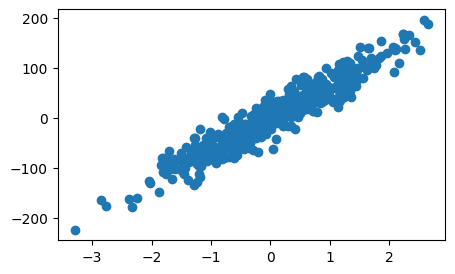

In [25]:
plt.figure(figsize=(5,3))
plt.scatter(x, y)

### Splitting dataset

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)

In [28]:
x_train.shape, x_test.shape

((400, 1), (100, 1))

### Train the LinearRegression of scikit-learn

In [29]:
from sklearn.linear_model import LinearRegression

In [30]:
lr = LinearRegression()

In [31]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
print(f'Slope: {lr.coef_}')
print(f'Intercept: {lr.intercept_}')

Slope: [64.13039841]
Intercept: 1.212903635487133


### Finding accuracy of scikit-learn model

In [33]:
y_pred = lr.predict(x_test)

In [34]:
from sklearn.metrics import r2_score

In [35]:
r2_score(y_test, y_pred)

0.8842943190992248

### Defining our class

In [36]:
class GDRegression:
    def __init__(self, m=1, b=0, learn_rate=0.01, epoches=100):
        self.m = m
        self.b = b
        self.learn_rate = learn_rate
        self.epoches = epoches

    def fit(self, x, y):
        for _ in range(self.epoches):
            slope_loss_b = -2 * np.sum(y - self.m*x.ravel() - self.b)
            self.b = self.b - self.learn_rate*slope_loss_b
        
            slope_loss_m = -2 * np.sum((y - self.m*x.ravel() - self.b)*x.ravel())
            self.m = self.m - self.learn_rate*slope_loss_m

    def predict(self, x):
        return np.array([self.m*x.ravel() + self.b])

### checking our model

In [37]:
gd = GDRegression(learn_rate=0.001, epoches=100)
gd.fit(x_train, y_train)
print(f'Slope from GD: {gd.m}')
print(f'Intercept from GD: {gd.b}')

Slope from GD: 64.13039840948548
Intercept from GD: 1.212903635487132


In [38]:
y_pred_GD = gd.predict(x_test)

In [39]:
y_pred_GD.shape, y_test.shape

((1, 100), (100,))

In [41]:
r2_score(y_pred_GD.reshape(100), y_test.ravel())

0.8822484395037855